# Тестирование механизмов внимания на CIFAR-10

## Подготовка данных

In [26]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

trainset = torchvision.datasets.CIFAR10(root='../SequenceLab/data/cifar10', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root= '../SequenceLab/data/cifar10', train=False, download=True, transform=transform_test)


batch_size = 64
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4)

## Реализация модели

### Слои внимания

In [27]:
import sys
import torch
import time
import torch.nn.functional as F

sys.path.append('./code/stable')

from elsa_triton import ELSA_triton_fp32

In [28]:
B, H, N, D = 1, 12, 16384, 64
scale = D ** -0.5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

q = torch.randn(B, H, N, D, dtype=torch.float32, device=device)
k = torch.randn(B, H, N, D, dtype=torch.float32, device=device)
v = torch.randn(B, H, N, D, dtype=torch.float32, device=device)
ELSA_triton_fp32.apply(q, k, v, scale).shape

torch.Size([1, 12, 16384, 64])

In [78]:
import torch
import torch.nn as nn

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_channels=3, embed_dim=768):
        super().__init__()
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        B, C, H, W = x.shape
        x = self.proj(x).flatten(2).transpose(1, 2)
        return x

class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, seq_len):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.randn(1, seq_len + 1, embed_dim))  # Adjusted for [CLS] token

    def forward(self, x):
        return x + self.pos_embed

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, num_heads)

    def forward(self, x):
        return self.attn(x, x, x)[0]

class TransformerEncoderBlockELSA(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim):
        super().__init__()
        self.attn = ELSA_triton_fp32.apply
        self.num_heads = num_heads
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
    
    def get_view(self, x):
        # print(f"get_view input shape : {x.shape}")
        batch_size, seq_len, embed_dim = x.shape  # (64, 5, 768)
        head_dim = embed_dim // self.num_heads    # 768 // 8 = 96
        
        x = x.view(batch_size, seq_len, self.num_heads, head_dim)  # (64, 5, 8, 96)
        x = x.transpose(1, 2)                                      # (64, 8, 5, 96)
        
        return x
    
    def get_inverse_view(self, y):
        batch_size, num_heads, seq_len, head_dim = y.shape  # 4 переменные
        
        y = y.transpose(1, 2).contiguous()  # (batch_size, seq_len, num_heads, head_dim)
        
        embed_dim = num_heads * head_dim
        y = y.view(batch_size, seq_len, embed_dim)  # (batch_size, seq_len, embed_dim)
        return y

    def forward(self, x):        
        x_view = self.get_view(x)
        # print(f"attention input shape : {x_view.shape}")
        x = x + self.get_inverse_view(self.attn(x_view, x_view, x_view, self.num_heads))
        # print(f"attention output shape : {x.shape}")
        x = x + self.mlp(self.norm2(x))

        return x
    
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim):
        super().__init__()
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.num_heads = num_heads
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.ReLU(),
            nn.Linear(mlp_dim, embed_dim)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):        
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))

        return x

class VisionTransformer(nn.Module):
    def __init__(self, img_size=32, patch_size=16, num_classes=10, embed_dim=512, num_heads=8, depth=6, mlp_dim=1024, use_elsa=True):
        super().__init__()
        self.patch_embedding = PatchEmbedding(img_size, patch_size, 3, embed_dim)
        self.pos_encoding = PositionalEncoding(embed_dim, (img_size // patch_size) ** 2)
        self.transformer_blocks =  nn.ModuleList([
            TransformerEncoderBlockELSA(embed_dim, num_heads, mlp_dim) for _ in range(depth)
        ]) if use_elsa else nn.ModuleList([
            TransformerEncoderBlock(embed_dim, num_heads, mlp_dim) for _ in range(depth)
        ])
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.mlp_head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embedding(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.pos_encoding(x)
        for block in self.transformer_blocks:
            x = block(x)
        return self.mlp_head(x[:, 0])

## Обучение моделей

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")
device

device(type='cuda')

In [71]:
torch.cuda.empty_cache()

In [72]:
import torch.optim as optim
from torchvision import datasets, transforms
from tqdm import tqdm

model_elsa = VisionTransformer(img_size=32, use_elsa=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_elsa.parameters(), lr=0.001)

losses_elsa = []

# Training loop
for epoch in range(10):
    model_elsa.train()
    running_loss = 0.0
    for inputs, labels in tqdm(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model_elsa(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/10], Loss: {running_loss/len(trainloader)}")
    losses_elsa.append(running_loss/len(trainloader))

100%|██████████| 782/782 [00:21<00:00, 36.96it/s]


Epoch [1/10], Loss: 18.29464946927317


100%|██████████| 782/782 [00:20<00:00, 37.68it/s]


Epoch [2/10], Loss: 8.866035856554271


100%|██████████| 782/782 [00:20<00:00, 37.34it/s]


...

Epoch [8/10], Loss: 19.409894532254896


100%|██████████| 782/782 [00:21<00:00, 37.22it/s]


Epoch [9/10], Loss: 12.06951827710242


100%|██████████| 782/782 [00:20<00:00, 37.47it/s]

Epoch [10/10], Loss: 19.112813432503234


In [80]:
import torch.optim as optim
from torchvision import datasets, transforms

model_usual = VisionTransformer(img_size=32, use_elsa=False).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_usual.parameters(), lr=0.001)

losses_usual = []

# Training loop
for epoch in range(10):
    model_usual.train()
    running_loss = 0.0
    for inputs, labels in tqdm(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model_usual(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/10], Loss: {running_loss/len(trainloader)}")
    losses_usual.append(running_loss/len(trainloader))

100%|██████████| 782/782 [00:21<00:00, 36.33it/s]


Epoch [1/10], Loss: 2.554353965822693


100%|██████████| 782/782 [00:21<00:00, 36.30it/s]


Epoch [2/10], Loss: 2.329408909353759


100%|██████████| 782/782 [00:21<00:00, 36.42it/s]


...

Epoch [8/10], Loss: 2.3100062474570313


100%|██████████| 782/782 [00:21<00:00, 36.65it/s]


Epoch [9/10], Loss: 2.312423052080452


100%|██████████| 782/782 [00:21<00:00, 36.89it/s]

Epoch [10/10], Loss: 2.3088427096071755


In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch

def compute_metrics(model, testloader, device=None):
    """
    Вычисляет метрики классификации на тестовых данных.

    Args:
        model (torch.nn.Module): обученная модель.
        testloader (torch.utils.data.DataLoader): DataLoader с тестовыми данными.
        device (str, optional): устройство для вычислений ('cuda' или 'cpu').
                                 Если None, определяется автоматически.

    Returns:
        dict: словарь с метриками ('accuracy', 'precision', 'recall', 'f1')
              и также матрицей ошибок ('confusion_matrix').
    """
    if device is None:
        device = 'cuda'
    
    model.eval()
    model.to(device)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Вычисление метрик
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1    }
    
    return metrics


In [87]:
import pandas as pd

# Получение метрик
metrics_elsa = compute_metrics(model_elsa, testloader)
metrics_elsa = pd.DataFrame([metrics_elsa], index=['ELSA'])

metrics_usual = compute_metrics(model_usual, testloader)
metrics_usual = pd.DataFrame([metrics_usual], index=['USUAL'])

In [88]:
pd.concat([metrics_elsa, metrics_usual], axis=0)

,accuracy,precision,recall,f1
ELSA,0.1606,0.199999,0.1606,0.143788
USUAL,0.1000,0.010000,0.1000,0.018182


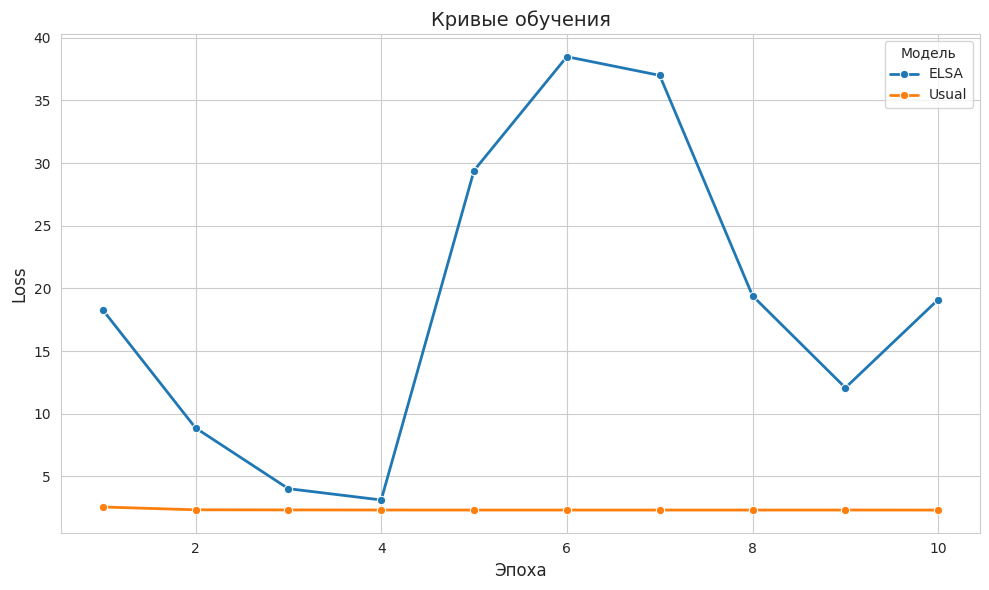

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def make_df(losses, name):
    epochs = list(range(1, len(losses) + 1))
    return pd.DataFrame({'Epoch': epochs, 'Loss': losses, 'Dataset': name})

df_elsa = make_df(losses_elsa, 'ELSA')
df_usual = make_df(losses_usual, 'Usual')

df_all = pd.concat([df_elsa, df_usual], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.lineplot(data=df_all, x='Epoch', y='Loss', hue='Dataset', marker='o', markersize=6, linewidth=2)

plt.title('Кривые обучения', fontsize=14)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss', fontsize=12)
# plt.ylim(2, 3)
plt.legend(title='Модель')
plt.tight_layout()

plt.show()

## Итог

Видно, что usual модель (с обычным вниманием) вообще не обучилась на данных (accuracy всё равно, что случайный ответ), однако elsa успела за 10 эпох чему-то научиться, что свидетельствует о её преимуществе над usual.
Возможно, elsa хороша с ситуациях сильно ограниченного по времени и ресурсам обучения